# Burgers Experiment

This notebook can be used to reproduce the results of section 4.2 and figure 5.
We already provide the experimental data from training runs in the folder
`burgers_data` and `burgers_trj`. In case you want to fully reproduce the
results, delete these folders beforehand.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from burgers_experiment import get_all_data, get_trj

/home/XXXX-22/miniconda3/envs/emu-sup-supplemental/lib/python3.12/site-packages/trainax/_general_trainer.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
configs = [
    {
        "network": network,
        "gamma_2": gamma_2,
        "delta_1": delta_1,
        "num_points": num_points,
        "ic_distribution": ic_distribution,
        "seed_init": seed_init,
        "seed_train": seed_train,
        "seed_test": seed_test,
        "seed_shuffle": seed_shuffle,
    }
    for network in [
        # "Conv;34;10;relu",
        "UNet;12;2;relu",  # 27'193 params, 29 receptive field per direction
        # "Res;26;8;relu",  # 32'943 params, 16 receptive field per direction
        # "FNO;12;18;4;gelu",  # 32'527 params, inf receptive field per direction
        # "Dil;2;32;2;relu",  # 31'777 params, 20 receptive field per direction
        # "Trans;28;4;4;relu",  # 31'669 params, inf receptive field per direction
    ]
    for (gamma_2, delta_1, num_points, ic_distribution) in [
        (0.2, -8.0, 60, "fourier;1;False;True"),
    ]
    for seed_init in range(30)
    for seed_train in range(100, 100+1)
    for seed_test in range(10_000, 10_000+1)
    for seed_shuffle in range(1_000_000, 1_000_000+1)
]

In [3]:
len(configs)

30

In [4]:
metrics, losses = get_all_data(configs)

100%|██████████| 30/30 [00:01<00:00, 17.56it/s]


In [5]:
metrics = pd.concat(metrics).reset_index(drop=True)
losses = pd.concat(losses).reset_index(drop=True)

In [6]:
trj_dict_seed_0 = get_trj(configs[0])

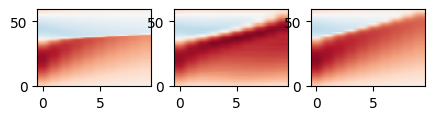

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(5, 1))

TRJ_IDX = 3 # Chosen because the IC is neatly centered in the domain

ax[0].imshow(
    trj_dict_seed_0["test_using_train_simulator"][TRJ_IDX][:, 0, :].T,
    origin="lower",
    cmap="RdBu_r",
    aspect="auto",
    vmin=-1,
    vmax=1,
)
ax[1].imshow(
    trj_dict_seed_0["test_neural"][TRJ_IDX][:, 0, :].T,
    origin="lower",
    cmap="RdBu_r",
    aspect="auto",
    vmin=-1,
    vmax=1,
)
ax[2].imshow(
    trj_dict_seed_0["test"][TRJ_IDX][:, 0, :].T,
    origin="lower",
    cmap="RdBu_r",
    aspect="auto",
    vmin=-1,
    vmax=1,
)

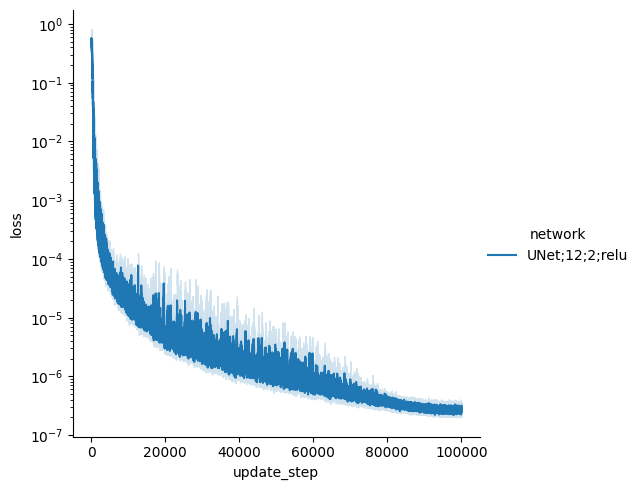

In [8]:
facet = sns.relplot(
    data=losses,
    x="update_step",
    y="loss",
    kind="line",
    hue="network",
    estimator="median",
    errorbar=("pi", 50),
)

for ax in facet.axes.flat:
    ax.set_yscale("log")

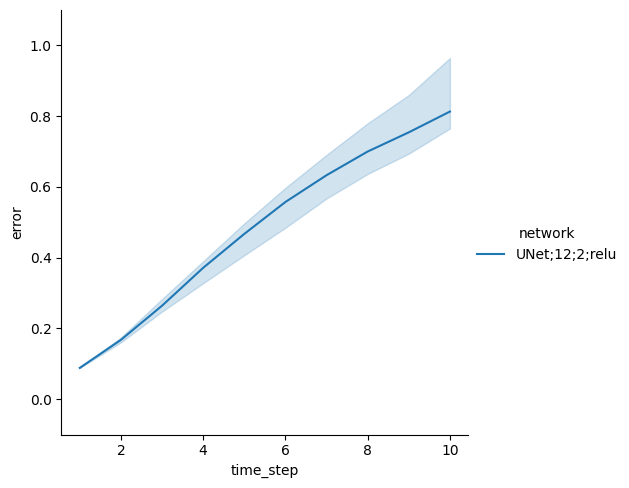

In [9]:
facet = sns.relplot(
    data=metrics.query("time_step <= 100"),
    x="time_step",
    y="error",
    hue="network",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
)

for ax in facet.axes.flat:
    ax.set_ylim(-0.1, 1.1)

In [10]:
metrics

,network,gamma_2,delta_1,num_points,ic_distribution,seed_init,seed_train,seed_test,seed_shuffle,superiority,error,time_step
0,UNet;12;2;relu,0.2,-8.0,60,fourier;1;False;True,0,100,10000,1000000,0.999035,0.088358,1
1,UNet;12;2;relu,0.2,-8.0,60,fourier;1;False;True,0,100,10000,1000000,0.757477,0.140774,2
2,UNet;12;2;relu,0.2,-8.0,60,fourier;1;False;True,0,100,10000,1000000,0.659070,0.203392,3
3,UNet;12;2;relu,0.2,-8.0,60,fourier;1;False;True,0,100,10000,1000000,0.665307,0.280649,4
4,UNet;12;2;relu,0.2,-8.0,60,fourier;1;False;True,0,100,10000,1000000,0.726319,0.371336,5
...,...,...,...,...,...,...,...,...,...,...,...,...
295,UNet;12;2;relu,0.2,-8.0,60,fourier;1;False;True,29,100,10000,1000000,1.011001,0.585708,6
296,UNet;12;2;relu,0.2,-8.0,60,fourier;1;False;True,29,100,10000,1000000,1.024619,0.650316,7
297,UNet;12;2;relu,0.2,-8.0,60,fourier;1;False;True,29,100,10000,1000000,1.039639,0.701244,8
298,UNet;12;2;relu,0.2,-8.0,60,fourier;1;False;True,29,100,10000,1000000,1.055062,0.744411,9


/tmp/ipykernel_915208/376915638.py:1: UserWarning: The palette list has more values (6) than needed (1), which may not be intended.
  facet = sns.relplot(


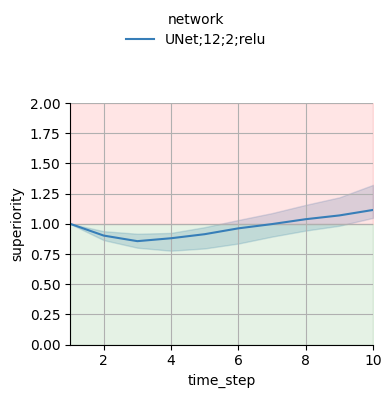

In [11]:
facet = sns.relplot(
    data=metrics.query("time_step <= 10"),
    x="time_step",
    y="superiority",
    hue="network",
    # col="setting",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    palette=["#377eb8", "#4daf4a", "#e41a1c", "#ff7f00", "#984ea3", "#a65628"],
    height=4,
)

for ax in facet.axes.flat:
    ax.set_ylim(0.0, 2.0)
    ax.fill_between(
        ax.lines[0].get_xdata(),
        0.0,
        1.0,
        color="green",
        alpha=0.1,
    )
    ax.fill_between(
        ax.lines[0].get_xdata(),
        1.0,
        2.0,
        color="red",
        alpha=0.1,
    )
    ax.set_xlim(1, 10)
    ax.grid()

facet.figure.subplots_adjust(top=0.75)

sns.move_legend(facet, "upper center", ncol=6)

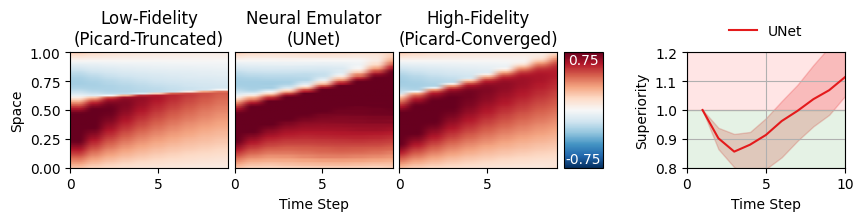

In [12]:
fig = plt.figure(figsize=(10, 1.5))

gs = fig.add_gridspec(1, 6, width_ratios=[1, 1, 1, 0.25, 0.45, 1], wspace=0.05)

ax_coarse = fig.add_subplot(gs[0, 0])
ax_neural = fig.add_subplot(gs[0, 1])
ax_fine = fig.add_subplot(gs[0, 2])
ax_colorbar = fig.add_subplot(gs[0, 3])
ax_metrics = fig.add_subplot(gs[0, 5])

TRJ_IDX = 3

im_coarse = ax_coarse.imshow(
    trj_dict_seed_0["test_using_train_simulator"][TRJ_IDX, :, 0, :].T,
    origin="lower",
    aspect="auto",
    vmin=-0.75,
    vmax=0.75,
    cmap="RdBu_r",
    extent=[0, 9, 0, 1],
)
im_neural = ax_neural.imshow(
    trj_dict_seed_0["test_neural"][TRJ_IDX, :, 0, :].T,
    origin="lower",
    aspect="auto",
    vmin=-0.75,
    vmax=0.75,
    cmap="RdBu_r",
)
im_fine = ax_fine.imshow(
    trj_dict_seed_0["test"][TRJ_IDX, :, 0, :].T,
    origin="lower",
    aspect="auto",
    vmin=-0.75,
    vmax=0.75,
    cmap="RdBu_r",
)

cbar = plt.colorbar(im_fine, cax=ax_colorbar)
cbar.set_ticks([])
# Add text labels for colorbar
ax_colorbar.text(
    0.5,
    0.01,
    "-0.75",
    ha="center",
    va="bottom",
    fontsize=10,
    transform=ax_colorbar.transAxes,
    color="white",
)
ax_colorbar.text(
    0.5,
    0.99,
    "0.75",
    ha="center",
    va="top",
    fontsize=10,
    transform=ax_colorbar.transAxes,
    color="white",
)

# cbar.set_ticks([-0.75, 0.75])
# cbar.ax.tick_params(size=0, labelsize=8, pad=1, direction='in')

# ax_metrics.plot(
#     range(1, len(metrics["superiority_trj"]) + 1), metrics["superiority_trj"]
# )
sns.lineplot(
    data=metrics.query("network== 'UNet;12;2;relu'"),
    x="time_step",
    y="superiority",
    ax=ax_metrics,
    estimator="median",
    errorbar=("pi", 50),
    hue="network",
    palette=["#e41a1c"],
)
ax_metrics.fill_between(
    range(0, len(metrics["superiority"]) + 1),
    0.0,
    1.0,
    color="green",
    alpha=0.1,
)
ax_metrics.fill_between(
    range(0, len(metrics["superiority"]) + 1),
    1.0,
    2.0,
    color="red",
    alpha=0.1,
)
ax_metrics.set_xlim(0, 10)

ax_neural.set_yticks([])
ax_fine.set_yticks([])

ax_coarse.set_xticks([0, 5, ])
ax_coarse.set_xlim(0, 9)
ax_neural.set_xticks([0, 5, ])
ax_neural.set_xlim(0, 9)
ax_fine.set_xticks([0, 5, ])
ax_fine.set_xlim(0, 9)
ax_metrics.set_xticks([0, 5, 10,])

ax_metrics.set_ylim(0.8, 1.2)
ax_metrics.set_yticks([0.8, 0.9, 1.0, 1.1, 1.2])
ax_metrics.grid()

ax_neural.set_xlabel("Time Step")
ax_coarse.set_ylabel("Space")

ax_metrics.set_ylabel("Superiority")
ax_metrics.set_xlabel("Time Step")

ax_coarse.set_title("Low-Fidelity\n(Picard-Truncated)")
ax_neural.set_title("Neural Emulator\n(UNet)")
ax_fine.set_title("High-Fidelity\n(Picard-Converged)")

# Move the legend above the axis
handles, labels = ax_metrics.get_legend_handles_labels()
ax_metrics.legend(handles=handles, labels=["UNet"], loc='upper center', bbox_to_anchor=(0.5, 1.35), ncol=len(labels), frameon=False)


fig.savefig("burgers_experiment.pdf", bbox_inches="tight")